In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import pandas as pd 
import uncertainties as u
from uncertainties import unumpy as unp
#import pandas as pd

Co57_Ge_spec = np.load("data/Co57-Ge Spectrum/spectrum_height.npy")
Co57_NaI_spec = np.load("data/Co57-NaI Spectrum/spectrum_height.npy")
Co60_Ge_spec = np.load("data/Co60-Ge Spectrum/spectrum_height.npy")
Co60_NaI_spec = np.load("data/Co60-NaI Spectrum/spectrum_height.npy")
Co60_co = np.genfromtxt("data/Co60 Coincidence/coincidences.csv", skip_header=True, delimiter=",")[:,3:6]

Cs137_Ge_spec = np.load("data/Cs137-Ge Spectrum/spectrum_height.npy")
Cs137_NaI_spec = np.load("data/Cs137-NaI Spectrum/spectrum_height.npy")

Na_22_co = np.genfromtxt("data/Na22 Coincidence/coincidences.csv", skip_header=True, delimiter=",")[:,3:5]
Na22_Ge_spec = np.load("data/Na22-Ge Spectrum/spectrum_height.npy")
Na22_NaI_spec = np.load("data/Na22-NaI Spectrum/spectrum_height.npy")

spectras_Ge = [Na22_Ge_spec,Na22_Ge_spec, Cs137_Ge_spec, Co57_Ge_spec,Co57_Ge_spec]
spectras_NaI = [Na22_NaI_spec, Na22_NaI_spec,Cs137_NaI_spec, Co57_NaI_spec]
probes = ["Na22 (1)","Na22 (2)", "Cs137", "Co57 (1)", "Co57 (2)"]

(4095,)


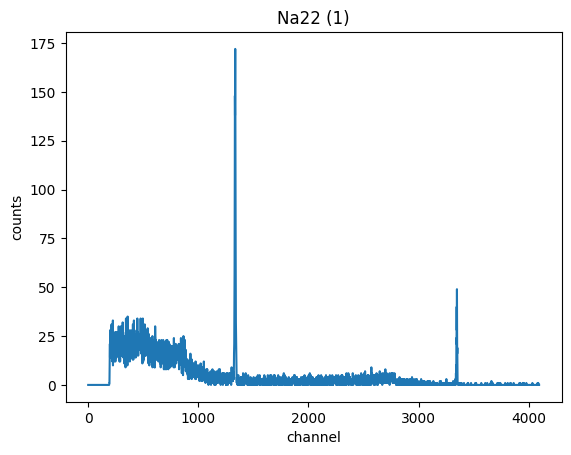

(4095,)


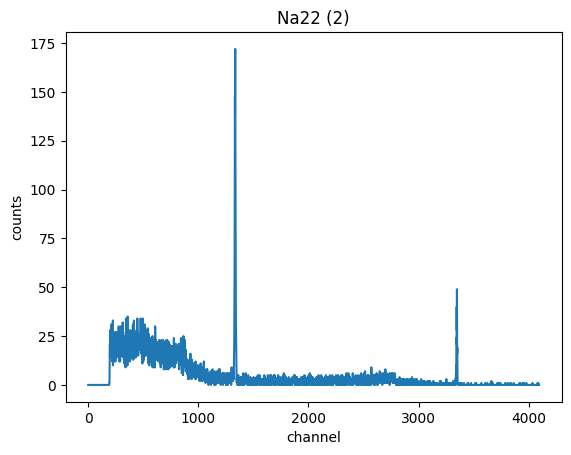

(4095,)


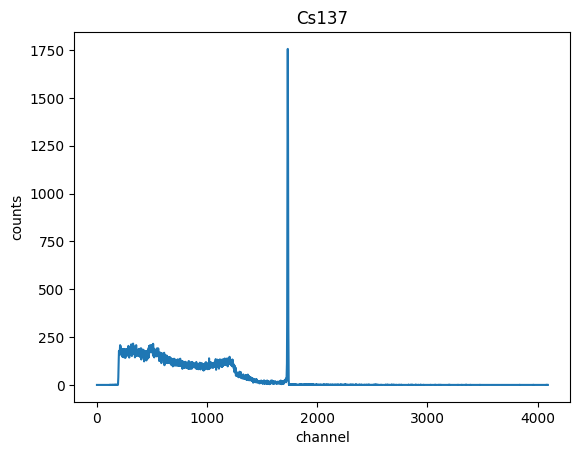

(4095,)


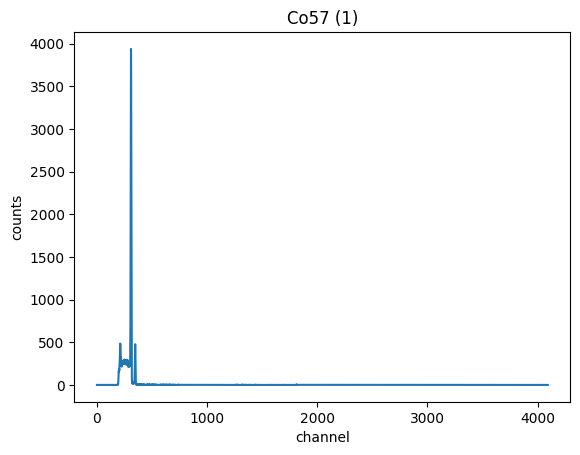

(4095,)


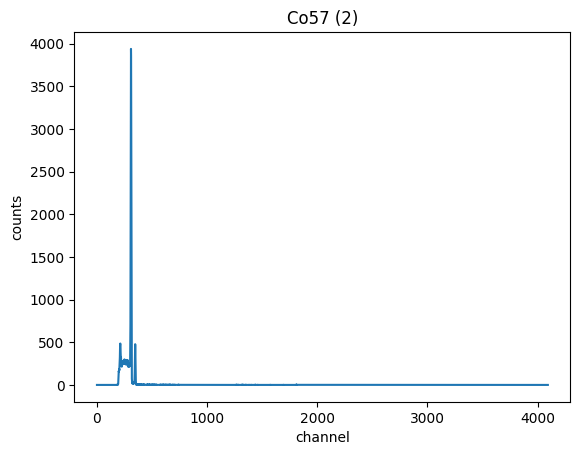

In [36]:
for i, spec in enumerate(spectras_Ge):
    print(spec.shape)
    plt.plot(np.arange(len(spec)), spec)
    plt.title(probes[i])
    plt.xlabel("channel")
    plt.ylabel("counts")
    plt.show()

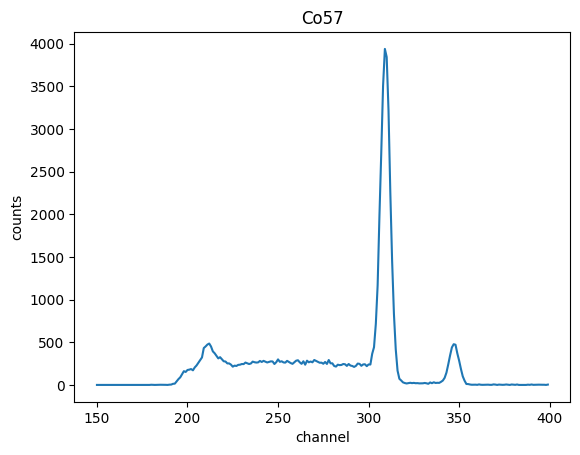

In [32]:
plt.plot(np.arange(len(Co57_Ge_spec))[150:400],Co57_Ge_spec[150:400])
plt.title("Co57")
plt.xlabel("channel")
plt.ylabel("counts")
plt.show()

## A1 Energiekalibration

## Energiekalibration Ge-Detektor

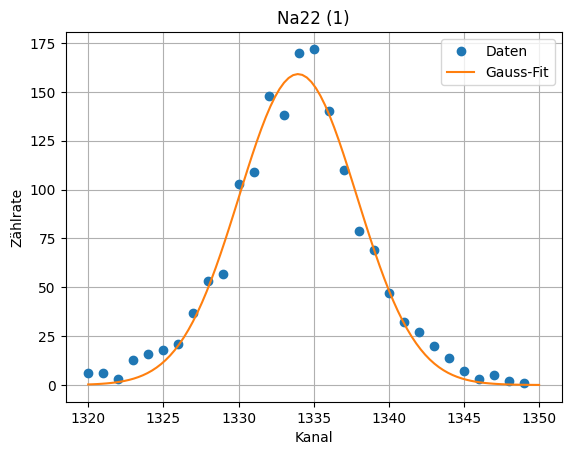

Amplitude: 159.13, Mittelwert: 1333.96, Sigma: 3.92


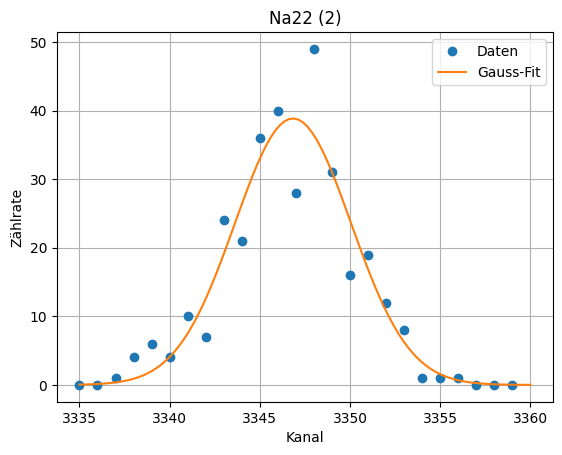

Amplitude: 38.86, Mittelwert: 3346.84, Sigma: 3.22


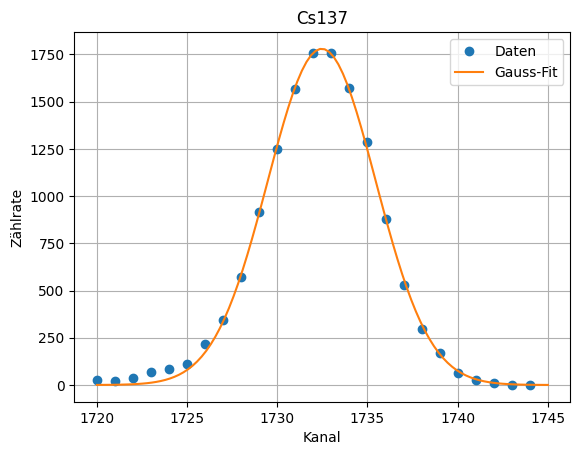

Amplitude: 1779.71, Mittelwert: 1732.46, Sigma: 2.99


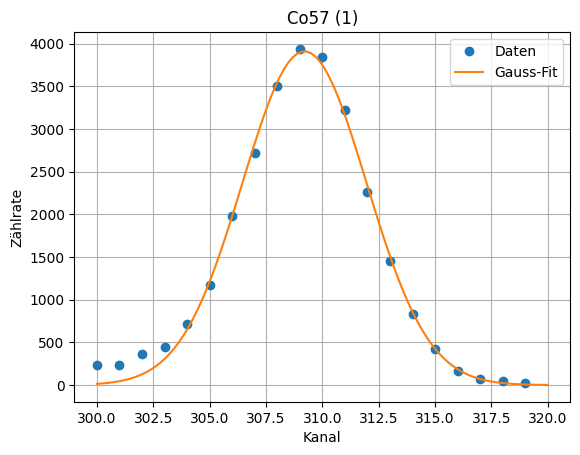

Amplitude: 3907.93, Mittelwert: 309.21, Sigma: 2.75


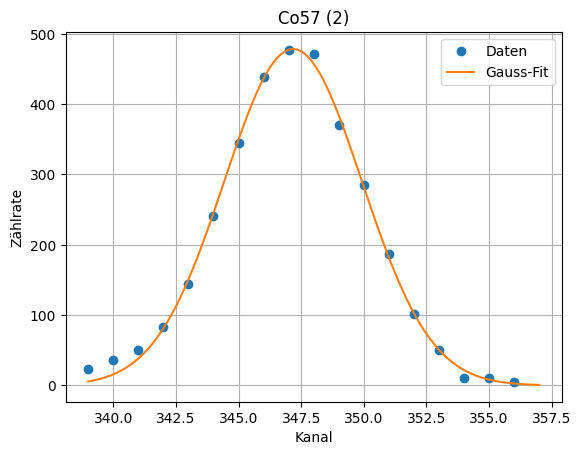

Amplitude: 478.52, Mittelwert: 347.18, Sigma: 2.75


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
area = np.array([[1320,1350], [3335,3360], [1720,1745], [300,320],[339,357]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr_ge1 = np.array([])
sigma_arr_ge= np.array([])
for i, spec in enumerate(spectras_Ge):

    xdata = np.arange(len(spec))[area[i,0]:area[i,1]]
    ydata = spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(area[i,0], area[i,1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr_ge1 = np.append(mu_arr_ge1, mu_fit)
    sigma_arr_ge = np.append(sigma_arr_ge, sigma_fit)


    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(area[i,0], area[i,1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Kanal")
    plt.ylabel("Zählrate")
    plt.title(probes[i])
    plt.grid(True)
    plt.savefig(f"include/Ge_calibration_{probes[i]}")
    plt.show()

    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


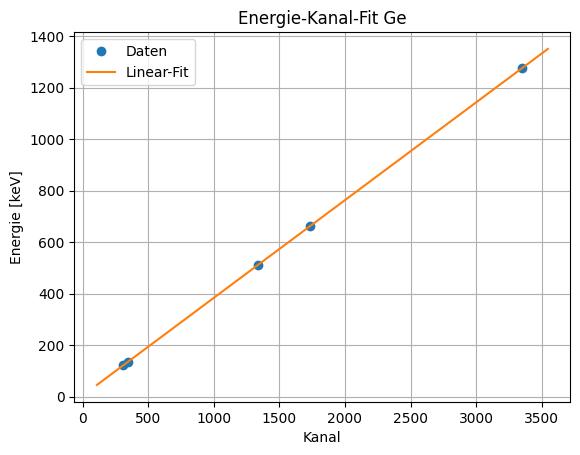

Steigung: 0.38, y-Aschsenabschnitt: 4.43


In [40]:
#print(mu_arr)
def Linear(x, m,c):
    return m*x +c 
Elit = [511,1275, 662, 122,136]

parameters, _ = curve_fit(Linear, mu_arr_ge1, Elit)

mg, cg = parameters
fit_y = Linear(np.linspace(np.min(mu_arr_ge1)-200, np.max(mu_arr_ge1)+200, 1000), mg, cg)

plt.plot(mu_arr_ge1, Elit, 'o', label='Daten')
plt.plot(np.linspace(np.min(mu_arr_ge1)-200, np.max(mu_arr_ge1)+200, 1000), fit_y, '-', label='Linear-Fit')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Energie [keV]")
plt.grid(True)
plt.title("Energie-Kanal-Fit Ge")
plt.savefig(f"include/Ge_calibration")
plt.show()

print(f"Steigung: {mg:.2f}, y-Aschsenabschnitt: {cg:.2f}")


## Energiekalibration NaJ-Detektor

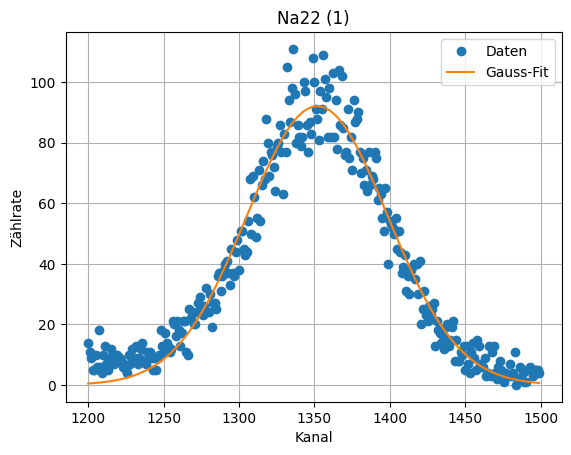

Amplitude: 92.09, Mittelwert: 1351.89, Sigma: 46.69


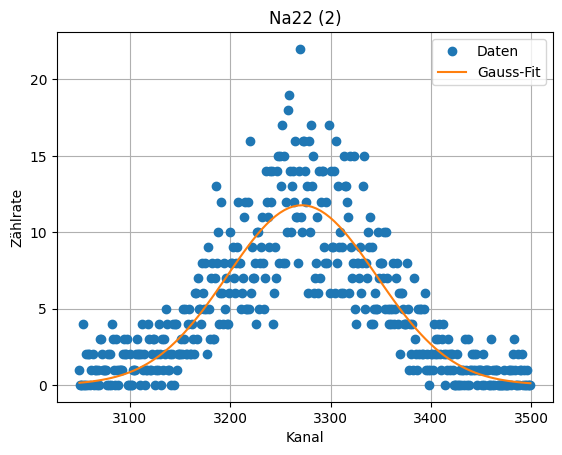

Amplitude: 11.77, Mittelwert: 3271.52, Sigma: 74.48


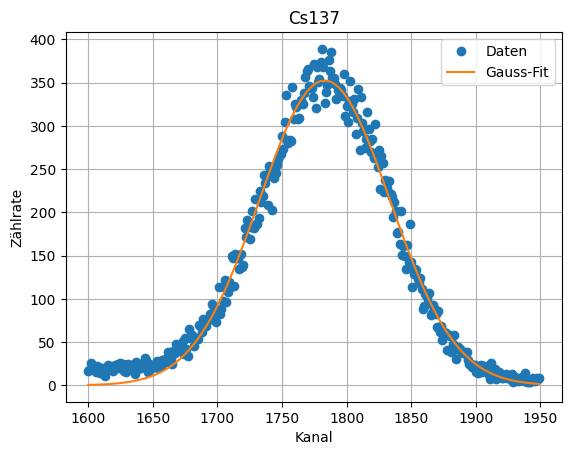

Amplitude: 352.49, Mittelwert: 1783.05, Sigma: 50.62


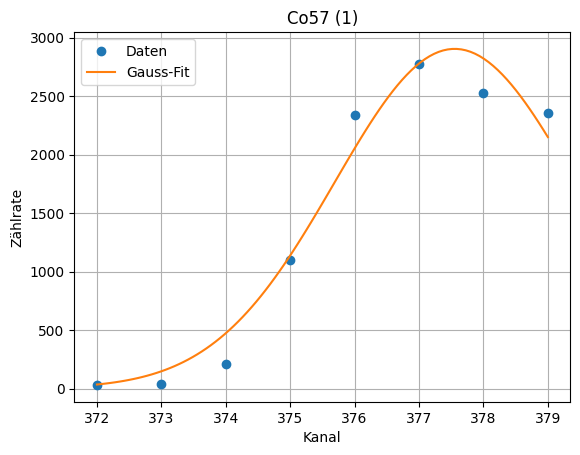

Amplitude: 2904.24, Mittelwert: 377.55, Sigma: 1.87


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
area = np.array([[1200,1500], [3050,3500], [1600,1950], [372,380]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr_naj = np.array([])
sigma_arr_naj = np.array([])
for i, spec in enumerate(spectras_NaI):

    xdata = np.arange(len(spec))[area[i,0]:area[i,1]]
    ydata = spec[area[i,0]:area[i,1]] 

    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)
    """
    if i ==3:
        A_fit, mu_fit, sigma_fit = parameters
        A_fit = 2600
        mu_fit = 377
        sigma_fit = 19
    else:
    """
    A_fit, mu_fit, sigma_fit = parameters
        
    fit_y = Gauss(np.linspace(area[i,0], area[i,1]-1, 100), A_fit, mu_fit, sigma_fit)
    
    mu_arr_naj = np.append(mu_arr_naj, mu_fit)
    sigma_arr_naj = np.append(sigma_arr_naj, sigma_fit)


    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(area[i,0], area[i,1]-1,100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Kanal")
    plt.ylabel("Zählrate")
    plt.title(probes[i])
    plt.grid(True)
    plt.savefig(f"include/NaI_calibration_{probes[i]}")

    plt.show()

    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


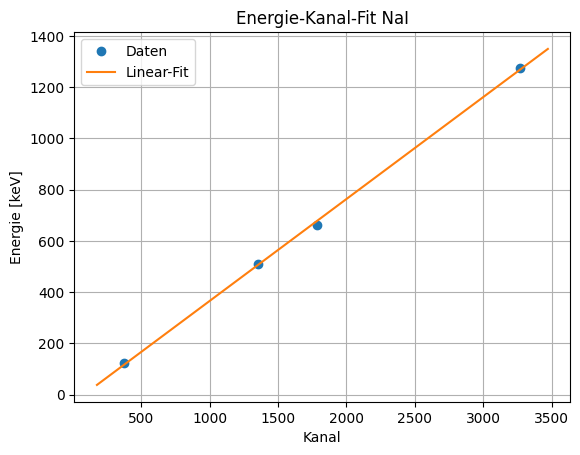

Steigung: 0.40, y-Aschsenabschnitt: -32.43


In [42]:
#print(mu_arr)
def Linear(x, m,c):
    return m*x +c 
Elit = [511,1275, 662, 122]

parameters, _ = curve_fit(Linear, mu_arr_naj, Elit)

mn, cn = parameters
fit_y = Linear(np.linspace(np.min(mu_arr_naj)-200, np.max(mu_arr_naj)+200, 1000), mn, cn)

#y_err = [46.69,74.48,50.62 ,2.53]
#plt.errorbar(mu_arr, Elit, yerr=y_err, fmt='o', capsize=5, label='Messwerte mit Fehler')
plt.plot(mu_arr_naj, Elit, 'o', label='Daten')
plt.plot(np.linspace(np.min(mu_arr_naj)-200, np.max(mu_arr_naj)+200, 1000), fit_y, '-', label='Linear-Fit')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Energie [keV]")
plt.grid(True)
plt.title("Energie-Kanal-Fit NaI")
plt.savefig(f"include/NaI_calibration")

plt.show()

print(f"Steigung: {mn:.2f}, y-Aschsenabschnitt: {cn:.2f}")


## A2 Co60 Spektrum

### Darstellung über Kanäle

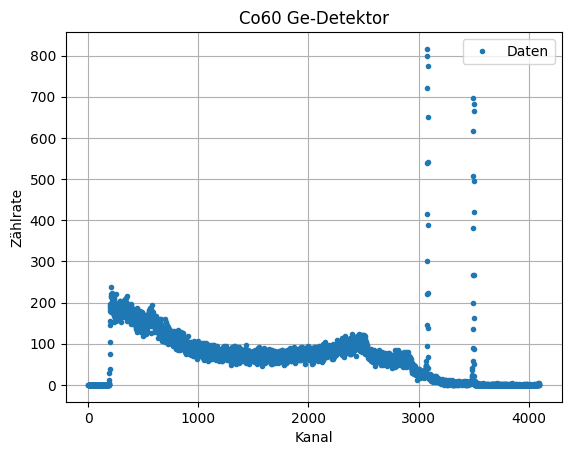

In [9]:
from scipy.signal import savgol_filter
xdata = np.arange(len(Co60_Ge_spec))
ydata = Co60_Ge_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Zählrate")
plt.title('Co60 Ge-Detektor')
plt.grid(True)
plt.savefig("include/Co60_spec_Ge_channel")
plt.show()


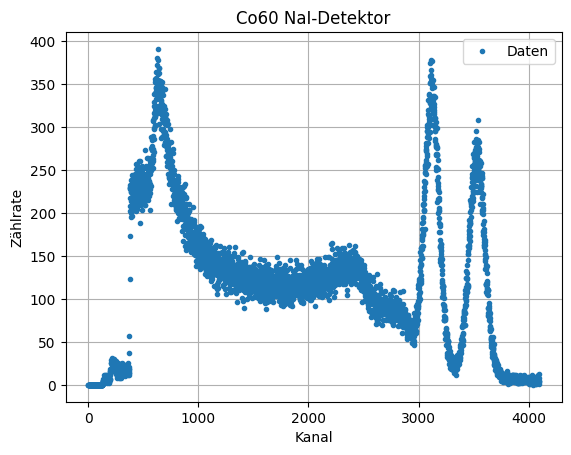

In [10]:
xdata = np.arange(len(Co60_NaI_spec))
ydata = Co60_NaI_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Kanal")
plt.ylabel("Zählrate")
plt.title('Co60 NaI-Detektor')
plt.grid(True)
plt.savefig("include/Co60_spec_NaI_channel")
plt.show()

### Fits für Ge-Detektor

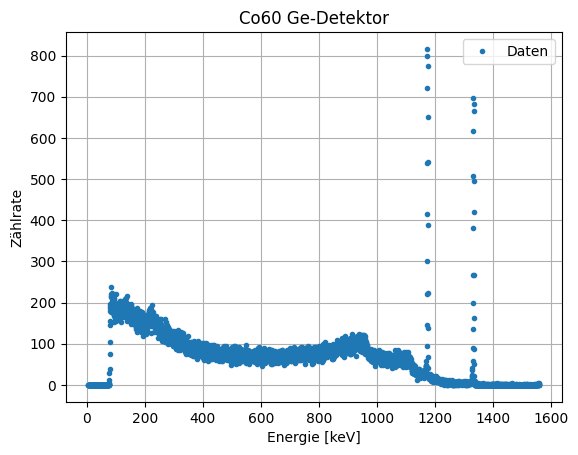

In [11]:
xdata = Linear(np.arange(len(Co60_Ge_spec)), mg  , cg  )
ydata = Co60_Ge_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Energie [keV]")
plt.ylabel("Zählrate")
plt.title('Co60 Ge-Detektor')
plt.grid(True)

plt.savefig("include/Co60_spec_Ge_energy")
plt.show()

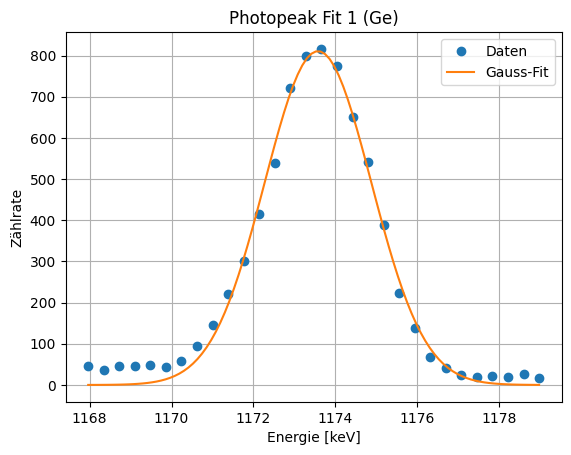

Amplitude: 810.59, Mittelwert: 1173.58, Sigma: 1.30


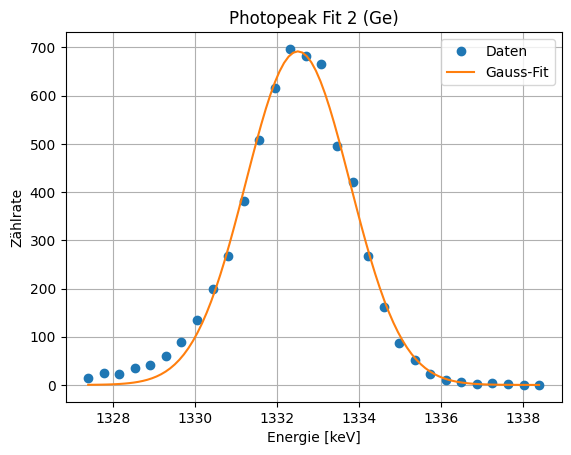

Amplitude: 691.96, Mittelwert: 1332.50, Sigma: 1.27


In [12]:
area = np.array([[3065,3095], [3485,3515]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr_ge = np.array([])
peaks_ge =np.array([])
sigmas_ge =np.array([])
for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_Ge_spec)), mg  , cg  )[area[i,0]:area[i,1]]
    ydata = Co60_Ge_spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr_ge = np.append(mu_arr_ge, mu_fit)
    peaks_ge = np.append(peaks_ge, mu_fit)
    sigmas_ge = np.append(sigmas_ge, sigma_fit)

    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Energie [keV]")
    plt.ylabel("Zählrate")
    plt.title(f'Photopeak Fit {i+1} (Ge)')
    plt.grid(True)
    plt.savefig(f"include/Co60_Ge_Photopeak_Fit_{i+1}")
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


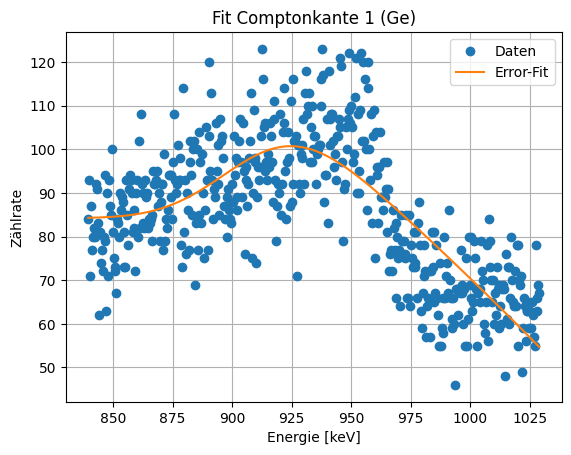

Amplitude: 64.90, Mittelwert: 910.98, Sigma: -24.50


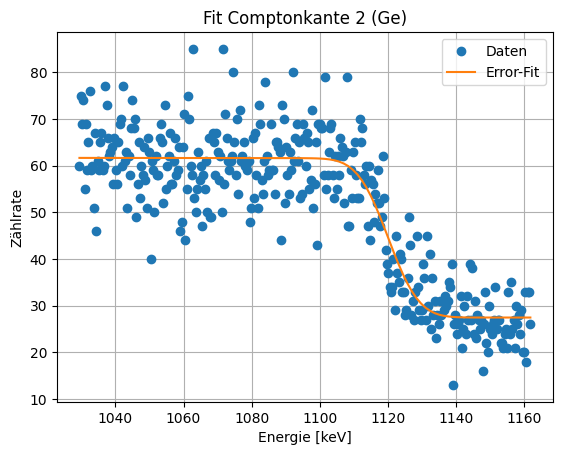

Amplitude: 17.19, Mittelwert: 1120.14, Sigma: 7.13


In [13]:
area = np.array([[2200,2700], [2700,3050]])

from scipy import special

def Compton_edge(x,A , mu, sigma = 10, baseline = 0,  B = 1):
    return A * special.erfc((x-mu)/(np.sqrt(2) * sigma)) * (1 + B * (x/mu - 0.5)**2) + baseline


def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_Ge_spec)), mg  , cg  )[area[i,0]:area[i,1]]
    ydata = Co60_Ge_spec[area[i,0]:area[i,1]] 
    
        # Bestimme grobe Startwerte aus den Daten
    A0 = np.max(ydata) - np.min(ydata)       # Amplitude (Höhe der Kante)
    mu0 = xdata[np.argmax(np.gradient(ydata))]  # Position der "Kante", wo der Gradient am größten ist
    sigma0 = (xdata[-1] - xdata[0]) / 20     # Breite der Kante, eher schmal (z. B. 1/20 des Bereichs)
    baseline0 = np.min(ydata)               # Unterster Wert als Basislinie
    B0 = 0.1                                # Leichter quadratischer Verlauf – meist klein

    p0 = [A0, mu0, sigma0, baseline0, B0]



    parameters, _ = curve_fit(Compton_edge, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit, baseline_fit, B_fit = parameters
    fit_y = Compton_edge(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit, baseline_fit, B_fit)
    mu_arr_ge = np.append(mu_arr_ge, mu_fit)
    peaks_ge = np.append(peaks_ge, mu_fit)
    sigmas_ge = np.append(sigmas_ge, sigma_fit)

    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Error-Fit')
    plt.legend()
    plt.xlabel("Energie [keV]")
    plt.ylabel("Zählrate")
    plt.title(f'Fit Comptonkante {i+1} (Ge)')
    plt.grid(True)
    plt.savefig(f"include/Co60_Ge_compton_edge_Fit_{i+1}")
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


(4095,)


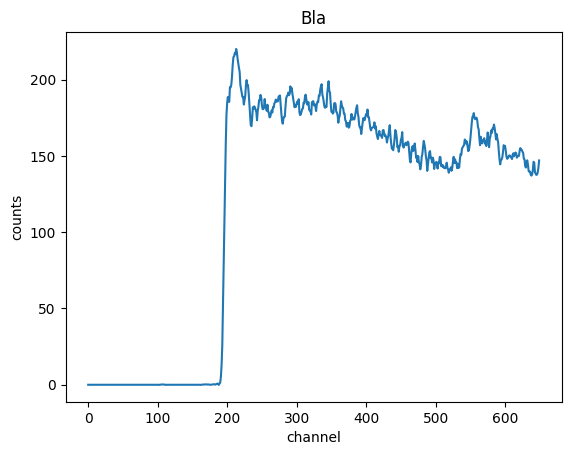

In [14]:
from scipy.signal import savgol_filter


arr = [0,650]
ydata = Co60_Ge_spec[arr[0]:arr[1]]
y_filtered = savgol_filter(ydata, window_length=11, polyorder=3)
print(spec.shape)
plt.plot(np.arange(len(Co60_Ge_spec))[arr[0]:arr[1]], y_filtered)
plt.title('Bla')
plt.xlabel("channel")
plt.ylabel("counts")
plt.show()

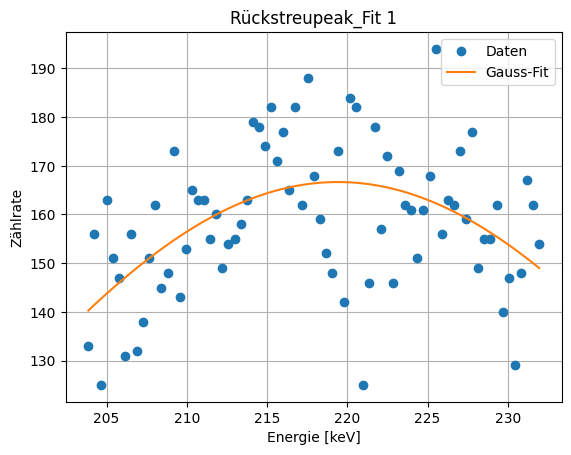

Amplitude: 166.67, Mittelwert: 219.41, Sigma: 26.48


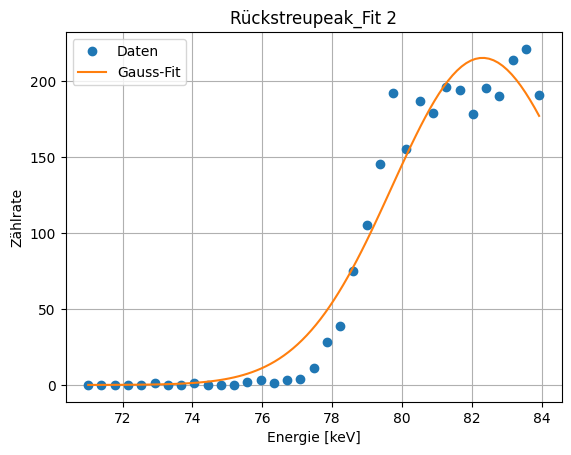

Amplitude: 215.11, Mittelwert: 82.30, Sigma: 2.59


In [15]:
area = np.array([[525,600], [175,210]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_Ge_spec)), mg  , cg  )[area[i,0]:area[i,1]]
    ydata = Co60_Ge_spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr_ge = np.append(mu_arr_ge, mu_fit)
    peaks_ge = np.append(peaks_ge, mu_fit)
    sigmas_ge = np.append(sigmas_ge, sigma_fit)

    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Energie [keV]")
    plt.ylabel("Zählrate")
    plt.title(f'Rückstreupeak_Fit {i+1}')
    plt.grid(True)
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


In [16]:
energy_co_spec = unp.uarray(peaks_ge, np.abs(sigmas_ge))

### Fits für NaI-Detektor

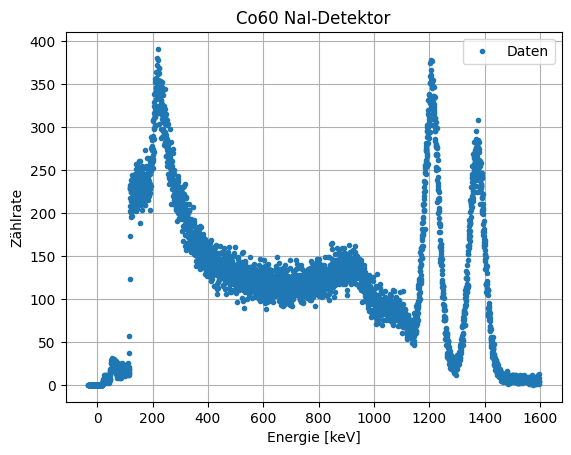

In [17]:
xdata = Linear(np.arange(len(Co60_NaI_spec)), mn  , cn  )
ydata = Co60_NaI_spec 

plt.plot(xdata, ydata, '.', label='Daten')
plt.legend()
plt.xlabel("Energie [keV]")
plt.ylabel("Zählrate")
plt.title('Co60 NaI-Detektor')
plt.grid(True)
plt.savefig("include/Co60_spec_NaI_energy")
plt.show()

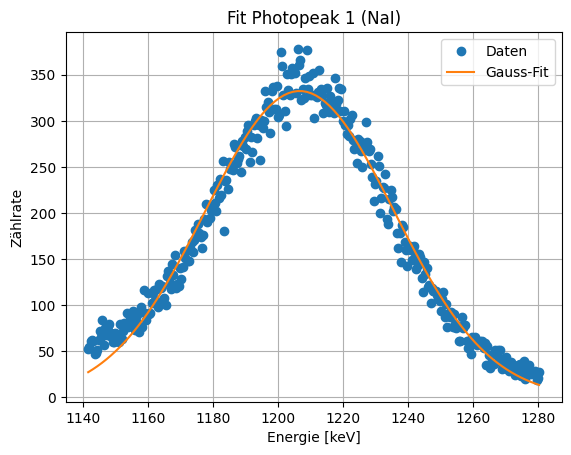

Amplitude: 332.34, Mittelwert: 1206.67, Sigma: 29.15


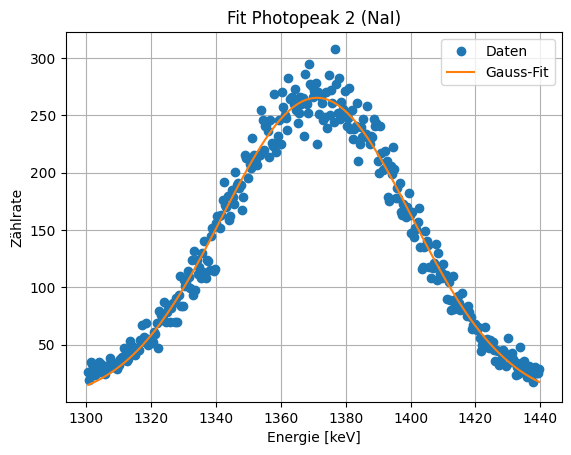

Amplitude: 265.36, Mittelwert: 1371.17, Sigma: 29.32


In [18]:
area = np.array([[2950,3300], [3350,3700]])

peaks_na = np.array([])
sigmas_na = np.array([])
mu_arr_na = np.array([])

def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr_na = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_NaI_spec)), mn  , cn  )[area[i,0]:area[i,1]]
    ydata = Co60_NaI_spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr_na = np.append(mu_arr_na, mu_fit)
    peaks_na = np.append(peaks_na, mu_fit)
    sigmas_na = np.append(sigmas_na, sigma_fit)

    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Energie [keV]")
    plt.ylabel("Zählrate")
    plt.title(f'Fit Photopeak {i+1} (NaI)')
    plt.grid(True)
    plt.savefig(f"include/Co60_NaI_Photopeak_Fit_{i+1}")
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


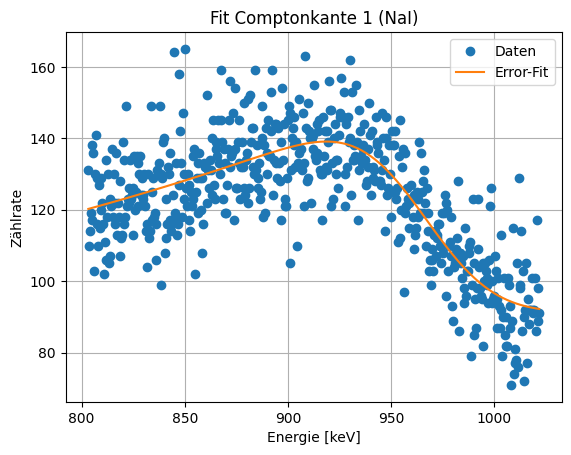

Amplitude: 1.70, Mittelwert: 961.80, Sigma: 26.73


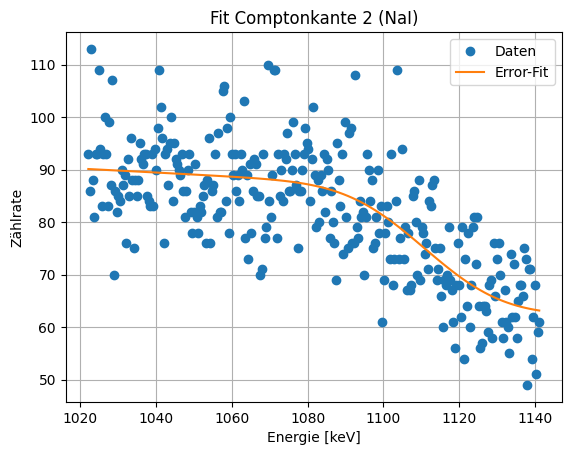

Amplitude: 18.17, Mittelwert: 1111.83, Sigma: 16.31


In [19]:
area = np.array([[2100,2650], [2650,2950]])

from scipy import special

def Compton_edge(x,A , mu, sigma = 10, baseline = 0,  B = 1):
    return A * special.erfc((x-mu)/(np.sqrt(2) * sigma)) * (1 + B * (x/mu - 0.5)**2) + baseline


def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_NaI_spec)), mn  , cn  )[area[i,0]:area[i,1]]
    ydata = Co60_NaI_spec[area[i,0]:area[i,1]] 
        # Bestimme grobe Startwerte aus den Daten
    A0 = np.max(ydata) - np.min(ydata)       # Amplitude (Höhe der Kante)
    mu0 = xdata[np.argmax(np.gradient(ydata))]  # Position der "Kante", wo der Gradient am größten ist
    sigma0 = (xdata[-1] - xdata[0]) / 20     # Breite der Kante, eher schmal (z. B. 1/20 des Bereichs)
    baseline0 = np.min(ydata)               # Unterster Wert als Basislinie
    B0 = 0.1                                # Leichter quadratischer Verlauf – meist klein

    p0 = [A0, mu0, sigma0, baseline0, B0]



    parameters, _ = curve_fit(Compton_edge, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit, baseline_fit, B_fit = parameters
    fit_y = Compton_edge(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit, baseline_fit, B_fit)
    mu_arr_na = np.append(mu_arr_na, mu_fit)
    peaks_na = np.append(peaks_na, mu_fit)
    sigmas_na = np.append(sigmas_na, sigma_fit)

    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Error-Fit')
    plt.legend()
    plt.xlabel("Energie [keV]")
    plt.ylabel("Zählrate")
    plt.title(f'Fit Comptonkante {i+1} (NaI)')
    plt.grid(True)

    plt.savefig(f"include/Co60_NaI_compton_edge_Fit_{i+1}")
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


(4095,)


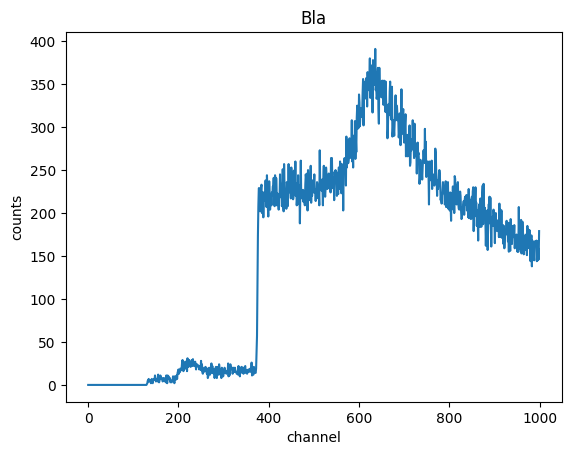

In [20]:
print(spec.shape)
arr = [0,1000]
plt.plot(np.arange(len(Co60_NaI_spec))[arr[0]:arr[1]], Co60_NaI_spec[arr[0]:arr[1]])
plt.title('Bla')
plt.xlabel("channel")
plt.ylabel("counts")
plt.show()

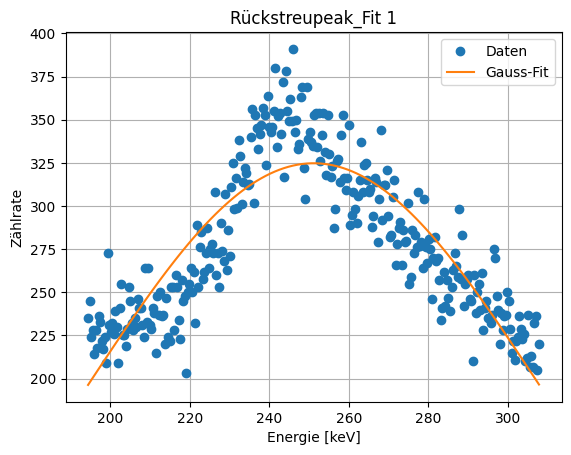

Amplitude: 324.77, Mittelwert: 251.16, Sigma: 56.60


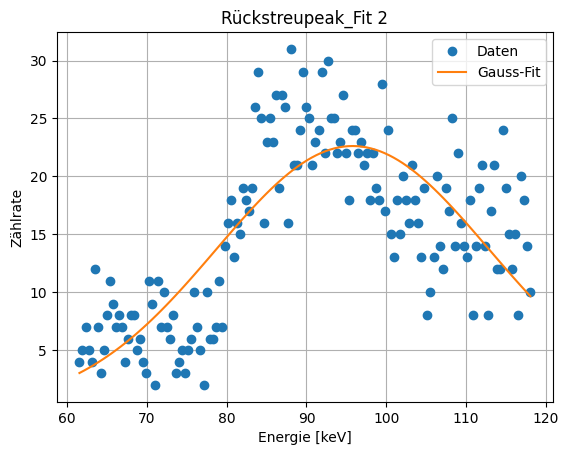

Amplitude: 22.62, Mittelwert: 95.79, Sigma: 17.09


In [21]:
area = np.array([[500,800], [150,300]])



def Gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)
mu_arr = np.array([])

for i in range(len(area)):

    xdata = Linear(np.arange(len(Co60_NaI_spec)), mg  , cg  )[area[i,0]:area[i,1]]
    ydata = Co60_NaI_spec[area[i,0]:area[i,1]] 
    
    p0 = [np.max(ydata), xdata[np.argmax(ydata)], 2]


    parameters, _ = curve_fit(Gauss, xdata, ydata, p0=p0)


    A_fit, mu_fit, sigma_fit = parameters
    fit_y = Gauss(np.linspace(xdata[0], xdata[-1], 100), A_fit, mu_fit, sigma_fit)
    mu_arr_na = np.append(mu_arr_na, mu_fit)
    peaks_na = np.append(peaks_na, mu_fit)
    sigmas_na = np.append(sigmas_na, sigma_fit)

    plt.plot(xdata, ydata, 'o', label='Daten')
    plt.plot(np.linspace(xdata[0], xdata[-1],100), fit_y, '-', label='Gauss-Fit')
    plt.legend()
    plt.xlabel("Energie [keV]")
    plt.ylabel("Zählrate")
    plt.title(f'Rückstreupeak_Fit {i+1}')
    plt.grid(True)
    plt.show()
    print(f"Amplitude: {A_fit:.2f}, Mittelwert: {mu_fit:.2f}, Sigma: {sigma_fit:.2f}")


In [43]:
energy_nai_spec = unp.uarray(peaks_na, np.abs(sigmas_na))

labels = [
    "Photopeak 1",
    "Photopeak 2",
    "Comptonkante 1",
    "Comptonkante 2",
    "Rückstreupeak 1",
    "Rückstreupeak 2"
]

# Create DataFrame
df = pd.DataFrame({
    "Peak": labels,
    "Energie in keV (NaJ)": energy_nai_spec,
    "Energie in keV (Ge)": energy_co_spec
})

# Export to LaTeX
latex_table = df.to_latex(index=False, escape=False, column_format="lcc")

# Save to file (optional)
with open("include/energy_table.tex", "w", encoding="utf-8") as f:
    f.write("\\begin{table}[h]\n\\centering\n")
    f.write(df.to_latex(index=False, escape=False, column_format="lcc"))
    f.write("\\caption{Aus den Messdaten bestimmte Energien der Photopeaks, Comptonkanten und Rückstreupeaks für die $^60$Co-Quelle mit NaI- und Ge-Detektor}\n")
    f.write("\\label{tab:energy-calibration}\n")
    f.write("\\end{table}\n")

## A3 Koinzidenzanalyse

[ 450. -304. -149. ... -341.  101. -155.]


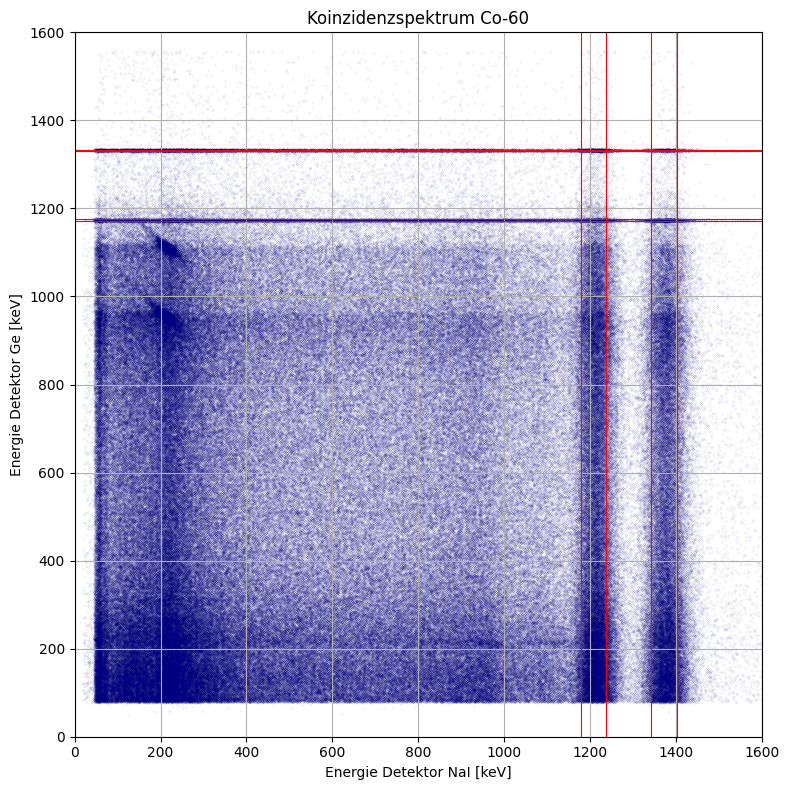

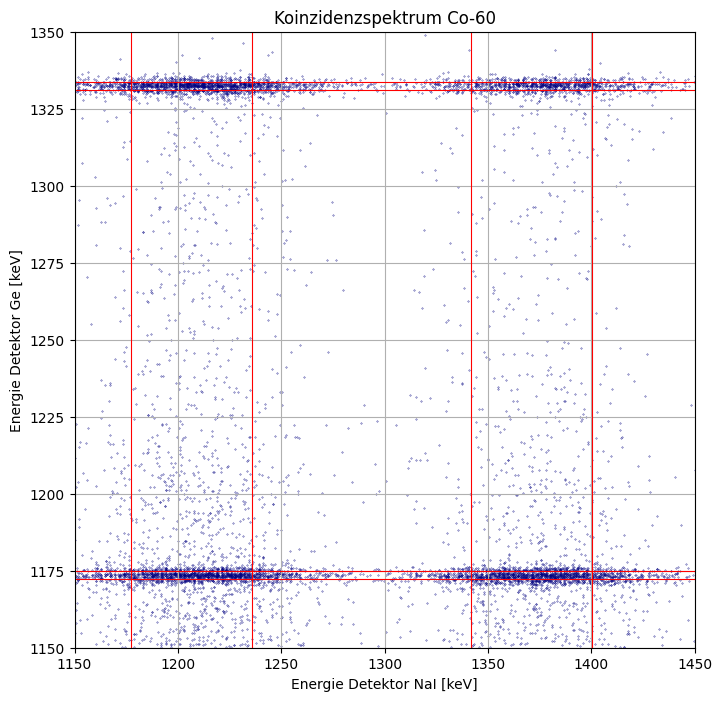

In [23]:

index = 6
# Aufteilen und in normale Listen umwandeln
split_peaks = np.array([peaks_ge.tolist(), peaks_na.tolist()])
split_sigmas = np.array([sigmas_ge.tolist(), sigmas_na.tolist()])
#print(split_peaks)
print(Co60_co[:, 2])
import matplotlib.pyplot as plt
xdata = Linear(Co60_co[:, 0][np.abs(Co60_co[:, 2])< 2000], mn, cn) #NaI
ydata = Linear(Co60_co[:, 1][np.abs(Co60_co[:, 2])< 2000], mg, cg) #Ge
"""
xdata = Linear(Co60_co[:, 0], mn, cn) #NaI
ydata = Linear(Co60_co[:, 1], mg, cg) #Ge
"""

a = 1

vertical_lines = [split_peaks[1,0]-a*split_sigmas[1,0],split_peaks[1,0]+a*split_sigmas[1,0],split_peaks[1,1]-a*split_sigmas[1,1],split_peaks[1,1]+a*split_sigmas[1,1]]     # in keV, z. B. Co-60 Photopeaks
horizontal_lines = [split_peaks[0,0]-a*split_sigmas[0,0],split_peaks[0,0]+a*split_sigmas[0,0],split_peaks[0,1]-a*split_sigmas[0,1],split_peaks[0,1]+a*split_sigmas[0,1]]   # gleiche Werte für y-Achse


plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, s=0.01, alpha=1, marker=".", color='navy')  # kleine, transparente Punkte

for vline in vertical_lines:
    plt.axvline(x=vline, color='red', linestyle='-', linewidth=0.8, label=f'v = {vline} keV')

# Horizontale Linien
for hline in horizontal_lines:
    plt.axhline(y=hline, color='red', linestyle='-', linewidth=0.8, label=f'h = {hline} keV')

plt.xlabel("Energie Detektor NaI [keV]")
plt.ylabel("Energie Detektor Ge [keV]")
plt.title("Koinzidenzspektrum Co-60")
plt.xlim(0, 1600)     # X-Achse z.B. von 0 bis 1500 keV
plt.ylim(0, 1600)     # Y-Achse z.B. von 0 bis 1500 keV
plt.grid(True)
#plt.axis("equal")  # gleiches Seitenverhältnis
plt.tight_layout()
plt.savefig("include/coincidence_Co60")
plt.show()


plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, s=0.3, alpha=1, marker=".", color='navy')  # kleine, transparente Punkte

for vline in vertical_lines:
    plt.axvline(x=vline, color='red', linestyle='-', linewidth=0.8, label=f'v = {vline} keV')

# Horizontale Linien
for hline in horizontal_lines:
    plt.axhline(y=hline, color='red', linestyle='-', linewidth=0.8, label=f'h = {hline} keV')

plt.xlabel("Energie Detektor NaI [keV]")
plt.ylabel("Energie Detektor Ge [keV]")
plt.title("Koinzidenzspektrum Co-60")
plt.xlim(1150, 1450)     # X-Achse z.B. von 0 bis 1500 keV
plt.ylim(1150, 1350)     # Y-Achse z.B. von 0 bis 1500 keV
plt.grid(True)
#plt.axis("equal")  # gleiches Seitenverhältnis
#plt.tight_layout()


plt.savefig("include/coincidence_Co60_closeup")

plt.show()


In [24]:

x1_min, x1_max, x2_min, x2_max = vertical_lines
y1_min, y1_max, y2_min, y2_max = horizontal_lines


xdata = np.array(xdata)
ydata = np.array(ydata)


mask1 = (xdata >= x1_min) & (xdata <= x1_max) & (ydata >= y1_min) & (ydata <= y1_max) #unten links
mask2 = (xdata >= x1_min) & (xdata <= x1_max) & (ydata >= y2_min) & (ydata <= y2_max) # oben links
mask3 = (xdata >= x2_min) & (xdata <= x2_max) & (ydata >= y1_min) & (ydata <= y1_max) # unten rechts
mask4 = (xdata >= x2_min) & (xdata <= x2_max) & (ydata >= y2_min) & (ydata <= y2_max) # oben rechts


region1_x, region1_y = xdata[mask1], ydata[mask1]
region2_x, region2_y = xdata[mask2], ydata[mask2]
region3_x, region3_y = xdata[mask3], ydata[mask3]
region4_x, region4_y = xdata[mask4], ydata[mask4]

regions = [[region1_x,region1_y], [region2_x,region2_y],[region3_x,region3_y],[region4_x,region4_y]]
for region in regions:
    print(len(region[0]), len(region[1]))

765 765
688 688
729 729
434 434


765


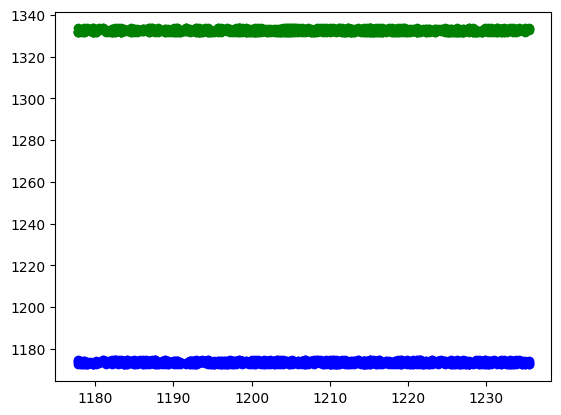

In [25]:
plt.scatter(region1_x, region1_y, color="blue")
plt.scatter(region2_x, region2_y, color="green")
print(sum(mask1))

$N_i^m(p) = p N_i^k + (1-p) N_i^u $

$\chi^2 = \sum^4_i \frac{(N_i - N_i^m(p))^2}{N_i^m(p)}$ 

$N_i^k = N_{ges} /2$

$N_i^u = N_{ges} /4$



In [26]:
from scipy.optimize import minimize_scalar
#Ereigniszahlen pro Fenster (N = [N2, N4, N1, N3])
N = np.array([len(regions[1][0]), len(regions[3][0]), len(regions[0][0]), len(regions[2][0])])
print(N)


N_total = np.sum(N)


Nm_u = np.full(4, N_total / 4)


Nm_k = np.array([N_total / 2, 0, 0, N_total / 2])


def model_counts(p):
    return p * Nm_k + (1 - p) * Nm_u

def chi_squared(p):
    Nm_p = model_counts(p)

    Nm_p_safe = np.where(Nm_p == 0, 1e-10, Nm_p)
    return np.sum((Nm_p - N)**2 / Nm_p_safe)

result = minimize_scalar(chi_squared, bounds=(0, 1), method='bounded')

p_opt = result.x
chi2_min = result.fun

print(f"Optimales p: {p_opt:.3f}")
print(f"Minimales χ²: {chi2_min:.3f}")


[688 434 765 729]
Optimales p: 0.065
Minimales χ²: 91.675


[ 510.9201317   662.1789924   121.95779745 1173.57610526 1332.50268068]
0.027394662498144498


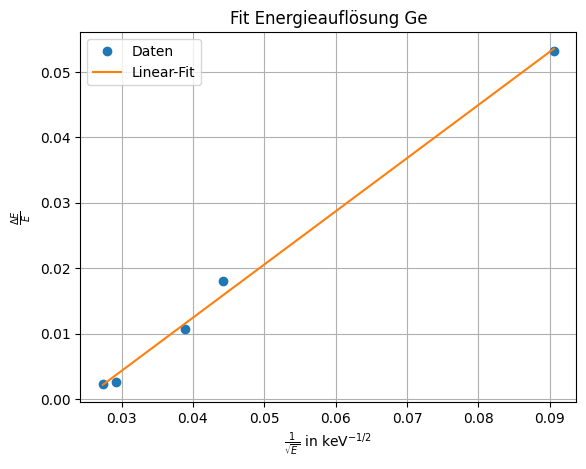

 Steigung: 0.81, y-Achsenabschnitt: -0.02


In [27]:


E_ge = Linear(mu_arr_ge1, mg, cg)
E_ge = np.delete(E_ge,1)
E_ge = np.append(E_ge,split_peaks[0][0])
E_ge = np.append(E_ge,split_peaks[0][1])
print(E_ge)

E_naj = Linear(mu_arr_naj, mn, cn)
E_naj = np.delete(E_naj,1)
E_naj = np.append(E_naj,split_peaks[1][0])
E_naj = np.append(E_naj,split_peaks[1][1])

dE_ge = sigma_arr_ge #* 2* np.sqrt(2*np.log(2)) 
dE_ge = np.delete(dE_ge,1)
dE_ge = np.append(dE_ge,split_sigmas[0][0])
dE_ge = np.append(dE_ge,split_sigmas[0][1])
dE_ge = dE_ge * 2* np.sqrt(2*np.log(2)) 

dE_naj = sigma_arr_naj# * 2* np.sqrt(2*np.log(2)) 
dE_naj = np.delete(dE_naj,1)
dE_naj = np.append(dE_naj,split_sigmas[0][0])
dE_naj = np.append(dE_naj,split_sigmas[0][1])
dE_naj = dE_naj * 2* np.sqrt(2*np.log(2)) 


xdata = 1/np.sqrt(E_ge)
ydata = dE_ge/ E_ge

parameters, _ = curve_fit(Linear, xdata, ydata)

print(xdata[-1])
mge, dge = parameters
fit_y = Linear(np.linspace(np.min(xdata), np.max(xdata),100), mge, dge)

plt.plot(xdata, ydata, 'o', label='Daten')
plt.plot(np.linspace(np.min(xdata), np.max(xdata),100), fit_y, '-', label='Linear-Fit')
plt.legend()
plt.xlabel(r'$\frac{1}{\sqrt{E}}\ \mathrm{in}\ \mathrm{keV}^{-1/2}$')
plt.ylabel(r"$\frac{\Delta E}{E}$ ")
plt.title(f'Fit Energieauflösung Ge')
plt.grid(True)
plt.savefig("include/Energieauflösung_Ge")
plt.show()
print(f" Steigung: {mge:.2f}, y-Achsenabschnitt: {dge:.2f}")




[0.04447475 0.03842911 0.09212754 0.02878767 0.02700566]


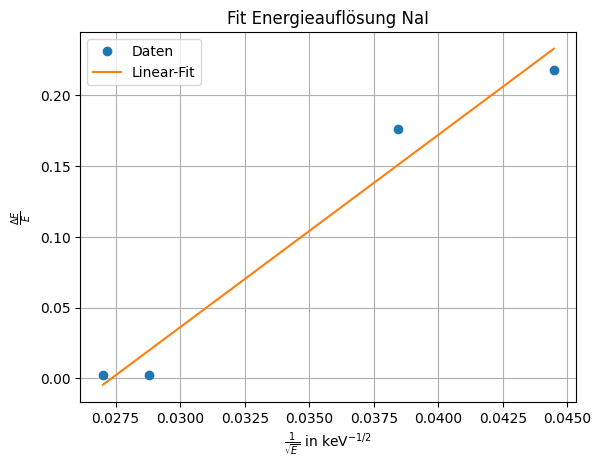

 Steigung: 13.56, y-Achsenabschnitt: -0.37
 Die Energieauflösung des Ge-Detektors ist circa um einen Faktor 16.68 besser als die des NaJ-Detektors


In [28]:
xdata = 1/np.sqrt(E_naj)
ydata = dE_naj/ E_naj
print(xdata)
xdata = np.delete(xdata,2)
ydata = np.delete(ydata,2)
parameters, _ = curve_fit(Linear, xdata, ydata)


mnaj, dnaj = parameters
fit_y = Linear(np.linspace(np.min(xdata), np.max(xdata),100), mnaj, dnaj)

plt.plot(xdata, ydata, 'o', label='Daten')
plt.plot(np.linspace(np.min(xdata), np.max(xdata),100), fit_y, '-', label='Linear-Fit')
plt.legend()
plt.xlabel(r'$\frac{1}{\sqrt{E}}\ \mathrm{in}\ \mathrm{keV}^{-1/2}$')
plt.ylabel(r"$\frac{\Delta E}{E}$ ")
plt.title(f'Fit Energieauflösung NaI')
plt.grid(True)
plt.savefig("include/Energieauflösung_NaI")
plt.show()
print(f" Steigung: {mnaj:.2f}, y-Achsenabschnitt: {dnaj:.2f}")

print(f" Die Energieauflösung des Ge-Detektors ist circa um einen Faktor {mnaj/mge:.2f} besser als die des NaJ-Detektors")